In [1]:
!pip install "numpy<2.0.0"
!pip install -q tensorflow pillow kagglehub scikit-learn seaborn matplotlib

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.2
    Uninstalling numpy-2.5.2:
      Successfully uninstalled numpy-2.5.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ml-dtypes 0.6.0 requires numpy>=2.0.0, but you have numpy 1.26.4 which is incompatible.
scipy 1.18.0 requires numpy<2.8,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 25.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.5.2 which is incompatible.

[notice] A new release of pip is available: 25.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

# Lendo o CSV de treinamento para vermos as colunas
df_imagens = pd.read_csv('csv/mass_case_description_train_set.csv')

# Exibindo as primeiras 3 linhas
display(df_imagens.head(3))

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...


In [3]:
import os
import shutil
import pandas as pd

base_dir = 'dataset_imagens'
os.makedirs(os.path.join(base_dir, 'maligno'), exist_ok=True)
os.makedirs(os.path.join(base_dir, 'benigno'), exist_ok=True)

df = pd.read_csv('csv/mass_case_description_train_set.csv')
pasta_origem_jpegs = 'jpeg'

print("1. Mapeando todas as imagens da pasta 'jpeg' (Isso pode levar alguns segundos)...")
mapa_imagens = {}

# Vasculha a pasta jpeg e guarda o caminho de cada foto associado ao seu código 1.3.6...
for root, dirs, files in os.walk(pasta_origem_jpegs):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            caminho_completo = os.path.join(root, file)
            # Quebra o caminho para pegar a pasta com o código 1.3.6...
            for parte in caminho_completo.replace('\\', '/').split('/'):
                if '1.3.6.1.4' in parte:
                    mapa_imagens[parte] = caminho_completo

print(f"-> {len(mapa_imagens)} pastas de imagens encontradas e mapeadas!")
print("2. Cruzando os dados com o CSV e copiando para a IA...")

copiados = 0
erros = 0

for index, row in df.iterrows():
    diagnostico = str(row['pathology']).strip().upper()
    pasta_destino = 'maligno' if diagnostico == 'MALIGNANT' else 'benigno'
    
    caminho_csv = str(row['image file path'])
    imagem_encontrada = False
    
    # Procura se algum código 1.3.6... dessa linha do CSV está no nosso mapa
    for parte_csv in caminho_csv.split('/'):
        if '1.3.6.1.4' in parte_csv:
            parte_csv = parte_csv.strip()
            if parte_csv in mapa_imagens:
                origem_arquivo = mapa_imagens[parte_csv]
                
                # Aproveitamos para dar um nome legível para a foto (ex: P_00001_LEFT_CC.jpg)
                nome_novo = f"{row['patient_id']}_{row['left or right breast']}_{row['image view']}.jpg"
                destino_arquivo = os.path.join(base_dir, pasta_destino, nome_novo)
                
                shutil.copy(origem_arquivo, destino_arquivo)
                copiados += 1
                imagem_encontrada = True
                break # Já achou a imagem dessa linha, vai pra próxima
                
    if not imagem_encontrada:
        erros += 1

print(f"--- Processo Concluído! ---")
print(f"✅ {copiados} imagens organizadas com sucesso na pasta 'dataset_imagens'.")
if erros > 0:
    print(f"⚠️ {erros} não encontradas (podem pertencer a outro arquivo CSV ou teste).")

1. Mapeando todas as imagens da pasta 'jpeg' (Isso pode levar alguns segundos)...
-> 0 pastas de imagens encontradas e mapeadas!
2. Cruzando os dados com o CSV e copiando para a IA...
--- Processo Concluído! ---
✅ 0 imagens organizadas com sucesso na pasta 'dataset_imagens'.
⚠️ 1318 não encontradas (podem pertencer a outro arquivo CSV ou teste).


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print(f"Versão do TensorFlow: {tf.__version__}")

# 1. Data augmentation — cria variações artificiais das imagens de treino
#    (rotação, espelhamento, zoom) para o modelo não decorar as fotos originais
gerador_treino = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
)

# A validação NUNCA recebe augmentation — precisa refletir dados reais
gerador_validacao = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

base_treino = gerador_treino.flow_from_directory(
    'dataset_imagens',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)

base_validacao = gerador_validacao.flow_from_directory(
    'dataset_imagens',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

print("\nMapeamento das classes:", base_treino.class_indices)

# 2. Calculando o peso de cada classe (caso a base esteja desbalanceada)
pesos_classes = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(base_treino.classes),
    y=base_treino.classes
)
dicionario_pesos = dict(enumerate(pesos_classes))
print("Pesos das classes (para compensar desbalanceamento):", dicionario_pesos)

# 3. Transfer Learning — usando o MobileNetV2 pré-treinado (ImageNet) como base
modelo_base = MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights='imagenet'
)
modelo_base.trainable = False  # Congela os pesos já aprendidos

modelo_cnn = models.Sequential([
    modelo_base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='Recall')]
)

modelo_cnn.summary()

# 4. Callbacks: para automaticamente antes de piorar, e reduz o
#    learning rate se o modelo estagnar
parada_antecipada = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reducao_taxa_aprendizado = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print("\n🚀 Iniciando o treinamento da Inteligência Artificial Visual...\n")

historico = modelo_cnn.fit(
    base_treino,
    epochs=25,
    validation_data=base_validacao,
    class_weight=dicionario_pesos,
    callbacks=[parada_antecipada, reducao_taxa_aprendizado]
)

print("\n--- Treinamento Concluído com Sucesso! ---")

Versão do TensorFlow: 2.21.0
Found 990 images belonging to 2 classes.
Found 247 images belonging to 2 classes.

Mapeamento das classes: {'benigno': 0, 'maligno': 1}
Pesos das classes (para compensar desbalanceamento): {0: np.float64(0.9744094488188977), 1: np.float64(1.0269709543568464)}


C:\Users\ferpo\AppData\Local\Temp\ipykernel_500\1690091555.py:61: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  modelo_base = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


🚀 Iniciando o treinamento da Inteligência Artificial Visual...

Epoch 1/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - Recall: 0.5187 - accuracy: 0.5192 - loss: 0.8621 - val_Recall: 0.2333 - val_accuracy: 0.5547 - val_loss: 0.7021 - learning_rate: 5.0000e-04
Epoch 2/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - Recall: 0.5207 - accuracy: 0.5394 - loss: 0.7865 - val_Recall: 0.3083 - val_accuracy: 0.5830 - val_loss: 0.6758 - learning_rate: 5.0000e-04
Epoch 3/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - Recall: 0.5726 - accuracy: 0.5576 - loss: 0.7016 - val_Recall: 0.2750 - val_accuracy: 0.5789 - val_loss: 0.6726 - learning_rate: 5.0000e-04
Epoch 4/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - Recall: 0.5249 - accuracy: 0.5616 - loss: 0.7026 - val_Recall: 0.5167 - val_accuracy: 0.5749 - val_loss: 0.6725 - learning_rate: 5.0000e-04
Epoch 5/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - Recall: 0.5581 - accuracy: 0.5616 - loss: 0.6851 - val_Recall: 0.8417 - val_accuracy: 0.5628 - val_loss: 0.6863 - l

RESUMO DO TREINAMENTO — CNN
---------------------------
Accuracy treino: 63.54%
Accuracy validação: 60.32%
Recall treino: 66.39%
Recall validação: 60.00%
Loss treino: 0.6459
Loss validação: 0.6629


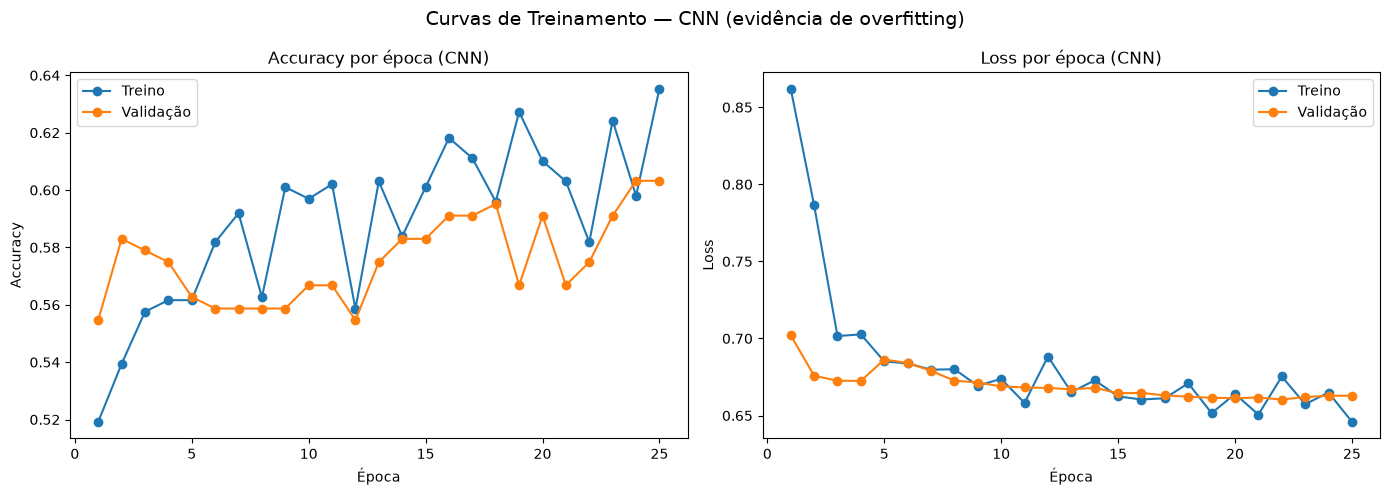

In [5]:
import matplotlib.pyplot as plt
from pathlib import Path

PASTA_IMAGENS = Path("imagens_resultados")
PASTA_IMAGENS.mkdir(parents=True, exist_ok=True)

acc = historico.history["accuracy"]
val_acc = historico.history["val_accuracy"]
recall = historico.history["Recall"]
val_recall = historico.history["val_Recall"]
loss = historico.history["loss"]
val_loss = historico.history["val_loss"]

print("RESUMO DO TREINAMENTO — CNN")
print("---------------------------")
print(f"Accuracy treino: {acc[-1]*100:.2f}%")
print(f"Accuracy validação: {val_acc[-1]*100:.2f}%")
print(f"Recall treino: {recall[-1]*100:.2f}%")
print(f"Recall validação: {val_recall[-1]*100:.2f}%")
print(f"Loss treino: {loss[-1]:.4f}")
print(f"Loss validação: {val_loss[-1]:.4f}")

epocas = range(1, len(acc) + 1)

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

eixos[0].plot(epocas, acc, "o-", label="Treino")
eixos[0].plot(epocas, val_acc, "o-", label="Validação")
eixos[0].set_title("Accuracy por época (CNN)")
eixos[0].set_xlabel("Época")
eixos[0].set_ylabel("Accuracy")
eixos[0].legend()

eixos[1].plot(epocas, loss, "o-", label="Treino")
eixos[1].plot(epocas, val_loss, "o-", label="Validação")
eixos[1].set_title("Loss por época (CNN)")
eixos[1].set_xlabel("Época")
eixos[1].set_ylabel("Loss")
eixos[1].legend()

plt.suptitle("Curvas de Treinamento — CNN (evidência de overfitting)", fontsize=14)
plt.tight_layout()
plt.savefig(PASTA_IMAGENS / "18_cnn_curvas_treinamento.png", dpi=300, bbox_inches="tight")
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step
RELATÓRIO DE CLASSIFICAÇÃO — CNN (validação)
---------------------------------------------
              precision    recall  f1-score   support

     benigno       0.58      0.61      0.59       127
     maligno       0.57      0.54      0.55       120

    accuracy                           0.57       247
   macro avg       0.57      0.57      0.57       247
weighted avg       0.57      0.57      0.57       247



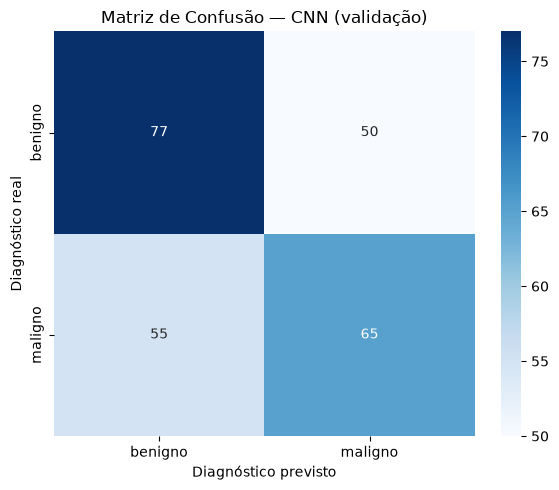

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from pathlib import Path

PASTA_IMAGENS = Path("imagens_resultados")
PASTA_IMAGENS.mkdir(parents=True, exist_ok=True)

base_validacao.reset()
previsoes_probabilidade = modelo_cnn.predict(base_validacao)
previsoes_classe = (previsoes_probabilidade > 0.5).astype(int).flatten()

rotulos_reais = base_validacao.classes
nomes_classes = list(base_validacao.class_indices.keys())

print("RELATÓRIO DE CLASSIFICAÇÃO — CNN (validação)")
print("---------------------------------------------")
print(classification_report(
    rotulos_reais,
    previsoes_classe,
    target_names=nomes_classes,
    zero_division=0
))

matriz_cnn = confusion_matrix(rotulos_reais, previsoes_classe)

plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nomes_classes,
    yticklabels=nomes_classes
)
plt.title("Matriz de Confusão — CNN (validação)")
plt.xlabel("Diagnóstico previsto")
plt.ylabel("Diagnóstico real")
plt.tight_layout()
plt.savefig(PASTA_IMAGENS / "19_cnn_matriz_confusao.png", dpi=300, bbox_inches="tight")
plt.show()